In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys

In [11]:
import os
print(os.getcwd())
print(os.listdir())

D:\fake job posting detection
['app', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [21]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

D:\fake job posting detection\data\fake_job_posting.csv


In [23]:
df = pd.read_csv(
    "D:/fake job posting detection/data/fake_job_posting.csv"
)

df.head()

,Job_id,Title,Location,Department,Salary_range,Company_profile,Description,Requirements,Benefits,Telecommuting,Has_company_logo,Has_questions,Employment_type,Required_experience,Required_education,Industry,Function,Fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [24]:
df.shape

(17880, 18)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Job_id               17880 non-null  int64 
 1   Title                17880 non-null  object
 2   Location             17534 non-null  object
 3   Department           6333 non-null   object
 4   Salary_range         2868 non-null   object
 5   Company_profile      14572 non-null  object
 6   Description          17879 non-null  object
 7   Requirements         15184 non-null  object
 8   Benefits             10668 non-null  object
 9   Telecommuting        17880 non-null  int64 
 10  Has_company_logo     17880 non-null  int64 
 11  Has_questions        17880 non-null  int64 
 12  Employment_type      14409 non-null  object
 13  Required_experience  10830 non-null  object
 14  Required_education   9775 non-null   object
 15  Industry             12977 non-null  object
 16  Func

In [26]:
missing_values = df.isnull().sum()

missing_values.sort_values(
    ascending=False
)

Salary_range           15012
Department             11547
Required_education      8105
Benefits                7212
Required_experience     7050
Function                6455
Industry                4903
Employment_type         3471
Company_profile         3308
Requirements            2696
Location                 346
Description                1
Title                      0
Job_id                     0
Telecommuting              0
Has_questions              0
Has_company_logo           0
Fraudulent                 0
dtype: int64

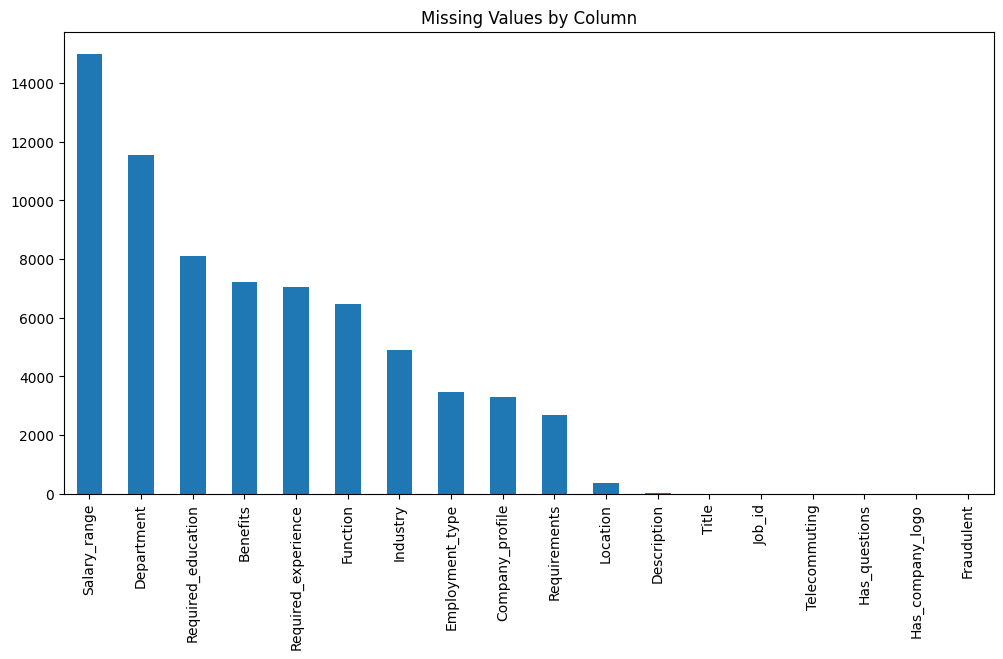

In [27]:
plt.figure(figsize=(12, 6))

df.isnull().sum().sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title(
    "Missing Values by Column"
)

plt.xticks(
    rotation=90
)

plt.show()

In [29]:
df["Fraudulent"].value_counts()

Fraudulent
0    17014
1      866
Name: count, dtype: int64

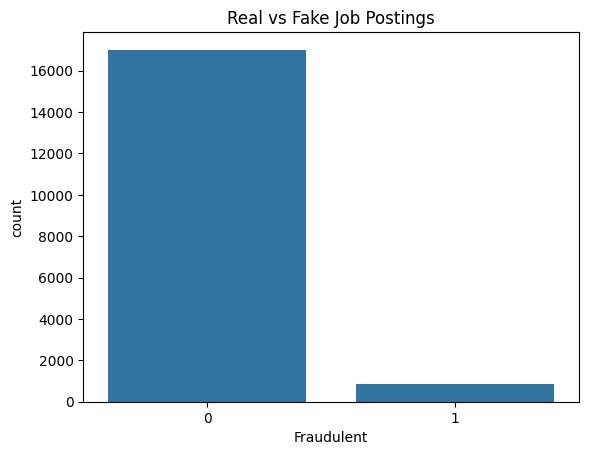

In [30]:
sns.countplot(
    x="Fraudulent",
    data=df
)

plt.title(
    "Real vs Fake Job Postings"
)

plt.show()

In [31]:
fake_percentage = (
    df["Fraudulent"].mean()
    * 100
)

print(
    f"Fake Jobs: {fake_percentage:.2f}%"
)

Fake Jobs: 4.84%
